# Walsh Coefficient Visualization

This notebook loads the Walsh coefficients and visualizes their distribution with a histogram, per-order comparisons, and a zero-centered density plot.

## 1. Load Data and Configure Plotting

Import libraries, load the dataset, and set a plotting style.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

csv_path = "./n1000_k2/instance_01.csv"

df = pd.read_csv(csv_path)
df.head()

,order,indices,coefficient
0,0,NaN,0.503292
1,1,430,-0.000884
2,1,150,0.000652
3,1,10,0.000634
4,1,276,0.000603


## 2. Per-Order Distributions 

Show coefficient distributions for clearer visibility of the actual shape.


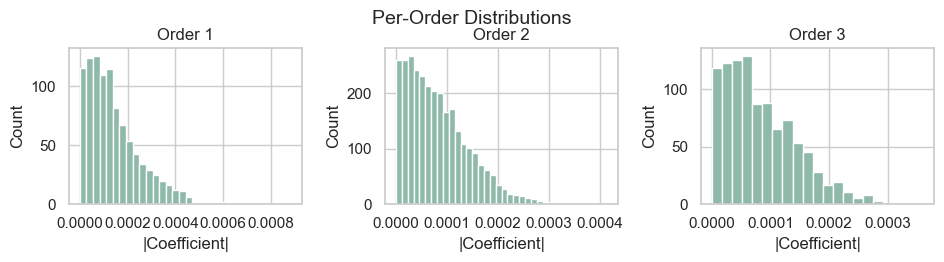

In [2]:
plot_df = df.copy()
plot_df["abs_coefficient"] = plot_df["coefficient"].abs()

orders = sorted([o for o in plot_df["order"].unique() if o != 0])
# Dynamically set cols based on number of orders, with a maximum of 10
cols = min(len(orders), 10)
rows = int(np.ceil(len(orders) / cols))

# Linear scale visualization
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.2, rows * 2.6), sharex=False, sharey=False)
axes = np.array(axes).reshape(-1)

for ax, order in zip(axes[:len(orders)], orders):
    data = plot_df.loc[plot_df["order"] == order, "abs_coefficient"]
    ax.hist(data, bins="fd", color="#8fb9a8", edgecolor="white")
    ax.set_title(f"Order {order}")
    ax.set_xlabel("|Coefficient|")
    ax.set_ylabel("Count")

for ax in axes[len(orders):]:
    ax.axis("off")

plt.tight_layout()
plt.suptitle("Per-Order Distributions", y=1.00, fontsize=14)
plt.show()


## 3. Coefficient Density Analysis - Theoretical vs Actual

Analyze how many coefficients exist per order compared to the theoretical maximum.
The theoretical maximum for order d is: n × C(k+1, d)



Inferred: n=1000, k=3

Order | Actual | Theoretical Max | Density %
------|--------|-----------------|----------
    1 |   1000 |            1000 |  100.00%
    2 |   5961 |            6000 |   99.35%
    3 |   4000 |            4000 |  100.00%
    4 |   1000 |            1000 |  100.00%



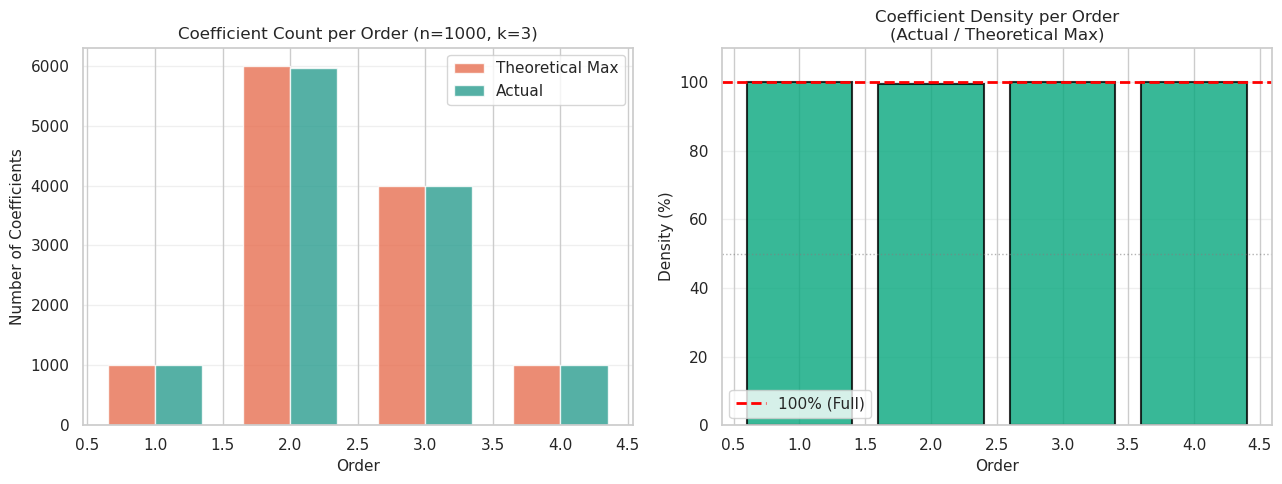

In [16]:
from scipy.special import comb

# Extract n and k from the CSV data
n = int(max(df[df['order'] > 0]['indices'].dropna().apply(
    lambda x: max([int(i) for i in str(x).split(';') if i])
))) + 1 if len(df[df['order'] > 0]) > 0 else None

if n is None:
    print("Could not determine n from data")
else:
    # Infer k from the maximum order
    max_order = int(df['order'].max())
    k = max_order - 1  # Since max order = k + 1 for NK landscape
    
    print(f"Inferred: n={n}, k={k}")
    print()
    
    # Calculate theoretical vs actual for each order (excluding order 0)
    analysis = []
    for order in sorted(df['order'].unique()):
        if order == 0:  # Skip order 0
            continue
        
        actual_count = int(len(df[df['order'] == order]))
        
        # Theoretical max depends on order:
        # Order 1: max = n (one per variable, due to NK structure overlap)
        # Order d >= 2: max = n × C(k+1, d)
        if order == 1:
            theoretical_max = n
        else:
            theoretical_max = int(n * comb(k + 1, int(order), exact=True))
        
        ratio = (actual_count / theoretical_max * 100) if theoretical_max > 0 else 0
        
        analysis.append({
            'order': int(order),
            'actual': int(actual_count),
            'theoretical_max': int(theoretical_max),
            'ratio_percent': float(ratio)
        })
    
    analysis_df = pd.DataFrame(analysis)
    print("Order | Actual | Theoretical Max | Density %")
    print("------|--------|-----------------|----------")
    for _, row in analysis_df.iterrows():
        print(f"{int(row['order']):5d} | {int(row['actual']):6d} | {int(row['theoretical_max']):15d} | {float(row['ratio_percent']):7.2f}%")
    print()
    
    # Plot: Theoretical vs Actual with density percentage
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    
    # Plot 1: Theoretical vs Actual counts
    x = analysis_df['order']
    width = 0.35
    ax1.bar(x - width/2, analysis_df['theoretical_max'], width, label='Theoretical Max', color='#e76f51', alpha=0.8)
    ax1.bar(x + width/2, analysis_df['actual'], width, label='Actual', color='#2a9d8f', alpha=0.8)
    ax1.set_xlabel('Order', fontsize=11)
    ax1.set_ylabel('Number of Coefficients', fontsize=11)
    ax1.set_title(f'Coefficient Count per Order (n={n}, k={k})', fontsize=12)
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # Plot 2: Density percentage
    colors = ['#d62828' if x < 50 else '#f77f00' if x < 80 else '#06a77d' 
              for x in analysis_df['ratio_percent']]
    ax2.bar(analysis_df['order'], analysis_df['ratio_percent'], color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax2.axhline(y=100, color='red', linestyle='--', linewidth=2, label='100% (Full)')
    ax2.axhline(y=50, color='gray', linestyle=':', linewidth=1, alpha=0.6)
    ax2.set_xlabel('Order', fontsize=11)
    ax2.set_ylabel('Density (%)', fontsize=11)
    ax2.set_title('Coefficient Density per Order\n(Actual / Theoretical Max)', fontsize=12)
    ax2.set_ylim([0, 110])
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
